# importing libararies

In [1]:
import pandas as pd
import numpy as np
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn import svm
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
# from sklearn.externals.six import StringIO  
from IPython.display import Image  
from sklearn.tree import export_graphviz
import seaborn as sns
import pydotplus

In [2]:
# !pip install pydotplus

# Read File

In [3]:
df = pd.read_csv('bank.csv')

In [4]:
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11157,33,blue-collar,single,primary,no,1,yes,no,cellular,20,apr,257,1,-1,0,unknown,no
11158,39,services,married,secondary,no,733,no,no,unknown,16,jun,83,4,-1,0,unknown,no
11159,32,technician,single,secondary,no,29,no,no,cellular,19,aug,156,2,-1,0,unknown,no
11160,43,technician,married,secondary,no,0,no,yes,cellular,8,may,9,2,172,5,failure,no


In [5]:
temp = df.columns.values[0]
temp

'age'

In [6]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


# Checking null values

In [7]:
df.isna().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

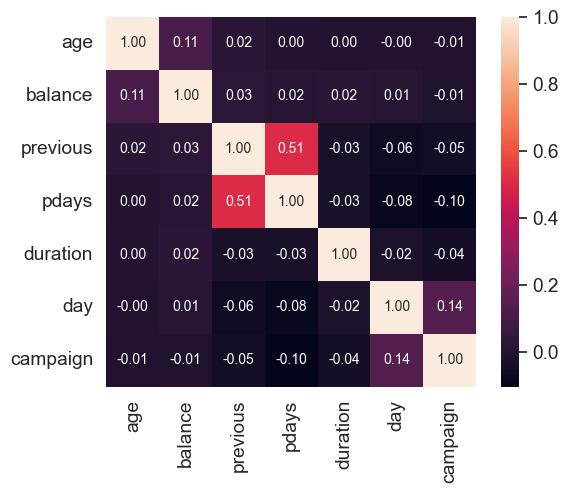

In [8]:
corrmat = df.corr(numeric_only=True)
k = 10 #number of variables for heatmap
cols = corrmat.nlargest(k, 'age')['age'].index
cm = np.corrcoef(df[cols].values.T)
sns.set(font_scale=1.25)
hm = sns.heatmap(cm, cbar=True, annot=True, square=True, fmt='.2f', annot_kws={'size': 10}, yticklabels=cols.values, xticklabels=cols.values)
plt.show()
#plt.figure(figsize=(10, 6))
#sns.set(font_scale = 1.00)
#sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='RdYlGn')

# Checking outliers

<Axes: >

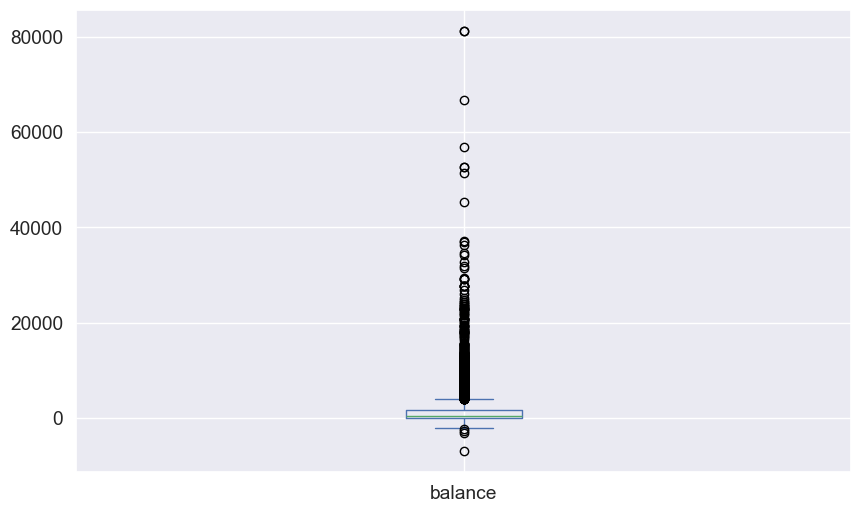

In [9]:
plt.figure(figsize=(10,6))
df.balance.plot(kind = 'box')

In [10]:
df['balance'].describe()

count    11162.000000
mean      1528.538524
std       3225.413326
min      -6847.000000
25%        122.000000
50%        550.000000
75%       1708.000000
max      81204.000000
Name: balance, dtype: float64

In [11]:
df.drop(df[df['balance']>1708].index,axis=0,inplace = True)

In [12]:
df.drop(df[df['balance']<122].index,axis=0,inplace = True)

In [13]:
(df['balance'] > 1708).sum()

np.int64(0)

In [14]:
(df['balance'] < 122).sum()

np.int64(0)

<Axes: >

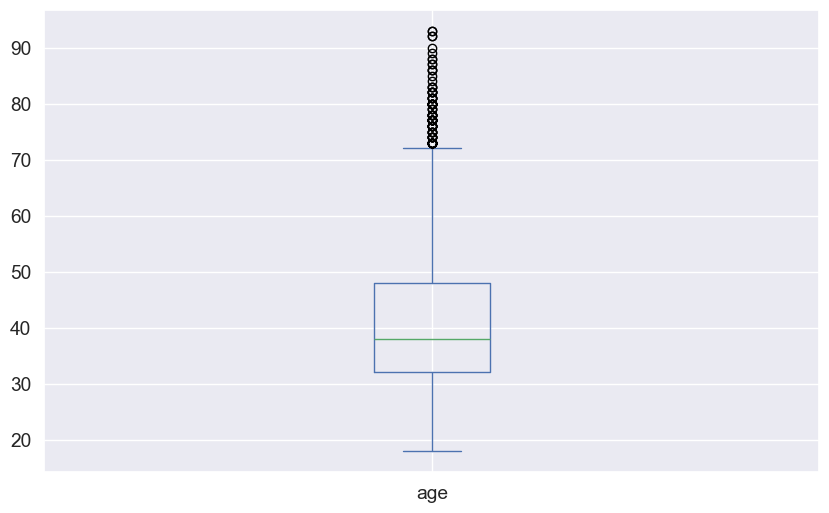

In [15]:
plt.figure(figsize=(10,6))
df.age.plot(kind = 'box')

In [16]:
df['age'].describe()

count    5589.000000
mean       40.385758
std        11.693628
min        18.000000
25%        32.000000
50%        38.000000
75%        48.000000
max        93.000000
Name: age, dtype: float64

In [17]:
df.drop(df[df['age']>48].index,axis=0,inplace = True)

In [18]:
df.drop(df[df['age']<32].index,axis=0,inplace = True)

<Axes: >

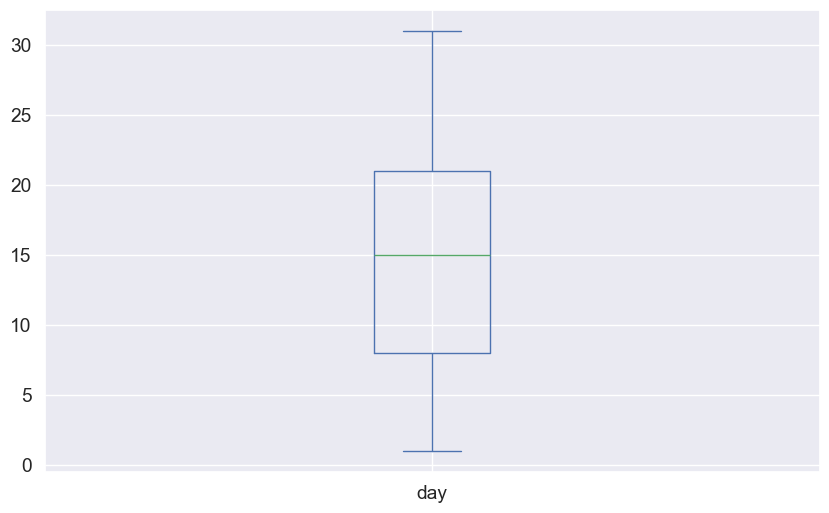

In [19]:
plt.figure(figsize=(10,6))
df.day.plot(kind = 'box')

In [20]:
df['day'].describe()

count    2896.000000
mean       15.275552
std         8.346845
min         1.000000
25%         8.000000
50%        15.000000
75%        21.000000
max        31.000000
Name: day, dtype: float64

In [21]:
df.drop(df[df['day']>21].index,axis=0,inplace = True)

In [22]:
df.drop(df[df['day']<8].index,axis=0,inplace = True)

<Axes: >

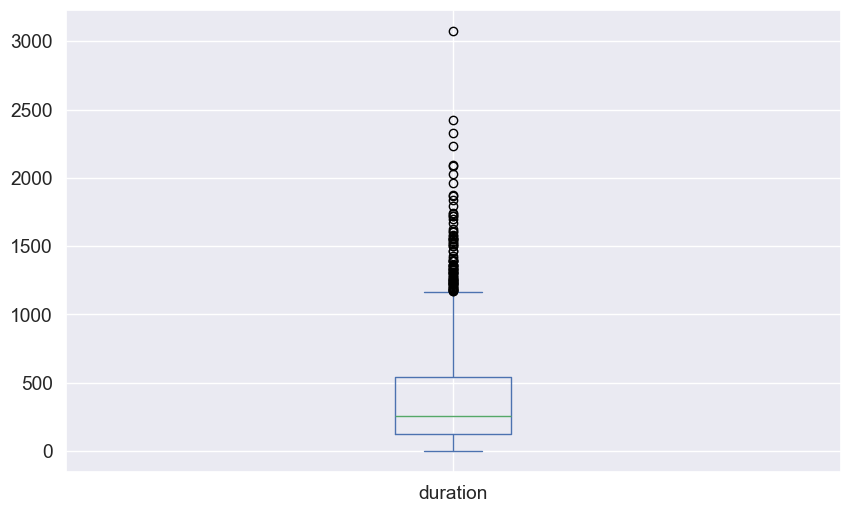

In [23]:
plt.figure(figsize=(10,6))
df.duration.plot(kind = 'box')

In [24]:
df['duration'].describe()

count    1552.000000
mean      389.233247
std       378.188830
min         2.000000
25%       126.750000
50%       254.500000
75%       541.500000
max      3076.000000
Name: duration, dtype: float64

In [25]:
df.drop(df[df['duration']>496].index,axis=0,inplace = True)

In [26]:
df.drop(df[df['duration']<138].index,axis=0,inplace = True)

<Axes: >

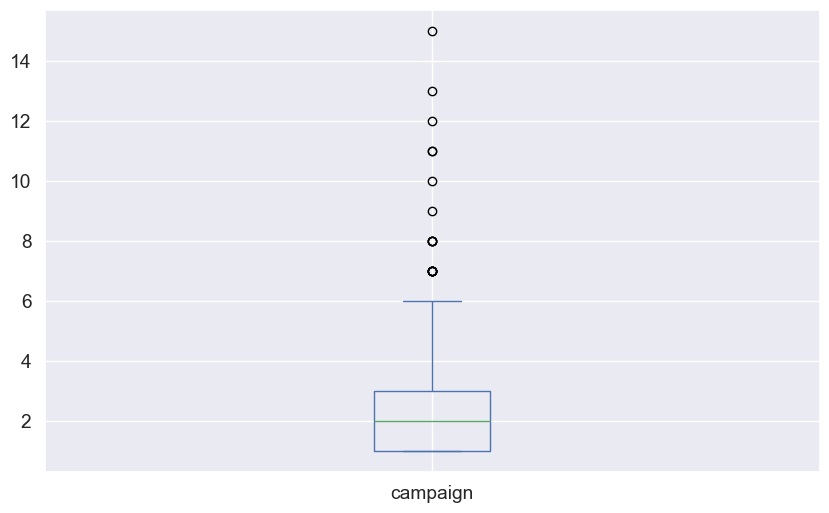

In [27]:
plt.figure(figsize=(10,6))
df.campaign.plot(kind = 'box')

In [28]:
df['campaign'].describe()

count    704.000000
mean       2.174716
std        1.660995
min        1.000000
25%        1.000000
50%        2.000000
75%        3.000000
max       15.000000
Name: campaign, dtype: float64

In [29]:
df.drop(df[df['campaign']>3].index,axis=0,inplace = True)

In [30]:
df.drop(df[df['campaign']<1].index,axis=0,inplace = True)

<Axes: >

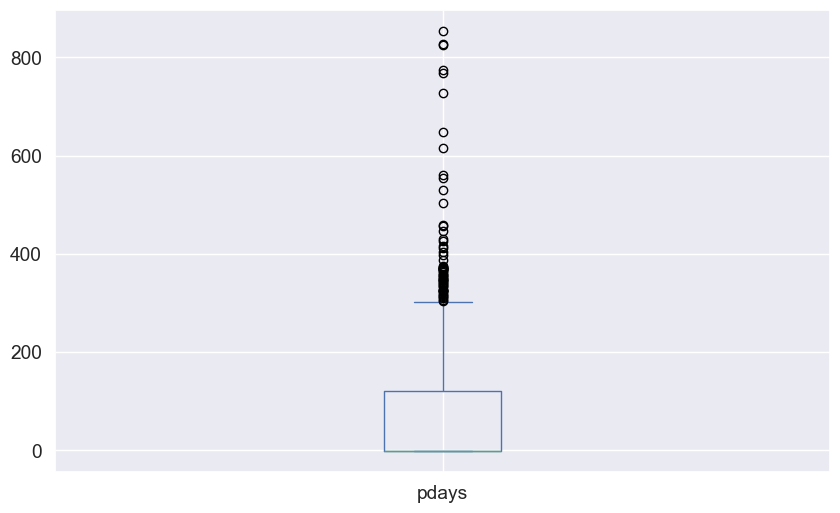

In [31]:
plt.figure(figsize=(10,6))
df.pdays.plot(kind = 'box')

In [32]:
df['pdays'].describe()

count    602.000000
mean      80.308970
std      144.978939
min       -1.000000
25%       -1.000000
50%       -1.000000
75%      120.500000
max      854.000000
Name: pdays, dtype: float64

In [33]:
df.drop(df[df['pdays']>120].index,axis=0,inplace = True)

In [34]:
df.drop(df[df['pdays']<-1].index,axis=0,inplace = True)

In [35]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
65,44,blue-collar,married,unknown,no,146,yes,no,unknown,15,may,483,1,-1,0,unknown,yes
484,39,technician,married,secondary,no,251,yes,no,cellular,17,jul,342,2,-1,0,unknown,yes
742,35,technician,single,secondary,no,354,no,no,cellular,11,aug,444,3,-1,0,unknown,yes
750,36,unemployed,divorced,secondary,no,871,no,no,cellular,12,aug,396,3,-1,0,unknown,yes
820,33,management,married,tertiary,no,1412,yes,no,unknown,19,aug,480,1,-1,0,unknown,yes


# Data Preprocessing

In [36]:
def preprocessor(df):
    res_df = df.copy()
    le = preprocessing.LabelEncoder()

    
    res_df['job'] = le.fit_transform(res_df['job'])
    res_df['marital'] = le.fit_transform(res_df['marital'])
    res_df['education'] = le.fit_transform(res_df['education'])
    res_df['default'] = le.fit_transform(res_df['default'])
    res_df['housing'] = le.fit_transform(res_df['housing'])
    res_df['loan'] = le.fit_transform(res_df['loan'])
    res_df['contact'] = le.fit_transform(res_df['contact'])
    res_df['month'] = le.fit_transform(res_df['month'])
    res_df['poutcome'] = le.fit_transform(res_df['poutcome'])
    res_df['deposit'] = le.fit_transform(res_df['deposit'])
    return res_df

In [37]:
encoded_df = preprocessor(df)
encoded_df.head(2)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
65,44,1,1,3,0,146,1,0,2,15,8,483,1,-1,0,3,1
484,39,9,1,1,0,251,1,0,0,17,5,342,2,-1,0,3,1


In [38]:
X = encoded_df.drop('deposit',axis = 1).values
Y = encoded_df['deposit'].values

# Split data into Train and Test data sets

In [39]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size = 0.2)

# Decision Tree model

<span style="font-size:20px">Decision Tree with Cart Gini</span>

## <span style="font-size:12px">Decision Tree with depth 2</span>

In [40]:
model_2 =  DecisionTreeClassifier(random_state=1,max_depth=2)
model_2.fit(X_train,Y_train)
model_2_score_train = model_2.score(X_train,Y_train)
model_2_score_test = model_2.score(X_test,Y_test)
print('Training score', model_2_score_train )
print('Test score', model_2_score_test)

Training score 0.7333333333333333
Test score 0.6923076923076923


## <span style="font-size:14px">Decision tree with depth 3</span>

In [41]:
model_3 =  DecisionTreeClassifier(random_state=1,max_depth=3)
model_3.fit(X_train,Y_train)
model_3_score_train = model_3.score(X_train,Y_train)
model_3_score_test = model_3.score(X_test,Y_test)
print('Training score', model_3_score_train )
print('Test score', model_3_score_test)

Training score 0.775
Test score 0.7472527472527473


## <span style="font-size:14px">Decision tree with depth 4</span>

In [42]:
model_4 =  DecisionTreeClassifier(random_state=1,max_depth=4)
model_4.fit(X_train,Y_train)
model_4_score_train = model_4.score(X_train,Y_train)
model_4_score_test = model_4.score(X_test,Y_test)
print('Training score', model_4_score_train )
print('Test score', model_4_score_test)

Training score 0.7861111111111111
Test score 0.7252747252747253


## <span style="font-size:14px">Decision tree with depth 5</span>

In [43]:
model_5 =  DecisionTreeClassifier(random_state=1,max_depth=5)
model_5.fit(X_train,Y_train)
model_5_score_train = model_5.score(X_train,Y_train)
model_5_score_test = model_5.score(X_test,Y_test)
print('Training score', model_5_score_train )
print('Test score', model_5_score_test)

Training score 0.8166666666666667
Test score 0.7362637362637363


In [44]:
pip install pydotplus

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [45]:
!pip install pydotplus


[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


<span style="font-size:20px">Decision Tree with c4.5(entropy)</span>

In [46]:
model_dt =  DecisionTreeClassifier(max_depth=2,criterion='entropy')
model_dt.fit(X_train,Y_train)
y_pred_dt = model_dt.predict_proba(X_test)[:,1]
model_dt_score_train = model_dt.score(X_train,Y_train)
model_dt_score_test = model_dt.score(X_test,Y_test)
print('Training score', model_dt_score_train )
print('Test score', model_dt_score_test)
print(y_pred_dt)

Training score 0.7416666666666667
Test score 0.7362637362637363
[0.37104072 0.37104072 0.37104072 0.37104072 0.825      0.825
 0.37104072 0.825      0.37104072 0.03191489 0.37104072 0.03191489
 0.37104072 0.37104072 0.37104072 0.37104072 0.825      0.37104072
 0.37104072 0.37104072 0.37104072 0.37104072 0.37104072 0.03191489
 0.37104072 0.03191489 0.37104072 0.37104072 0.03191489 0.37104072
 0.37104072 0.03191489 0.37104072 0.03191489 0.37104072 0.03191489
 0.37104072 0.37104072 0.03191489 0.37104072 0.825      0.03191489
 0.03191489 0.825      0.37104072 0.37104072 0.03191489 0.03191489
 0.03191489 0.37104072 0.03191489 0.03191489 0.37104072 0.03191489
 0.03191489 0.37104072 0.37104072 0.37104072 0.37104072 0.37104072
 0.03191489 0.03191489 0.37104072 0.37104072 0.37104072 0.03191489
 0.37104072 0.37104072 0.37104072 0.37104072 0.37104072 0.37104072
 0.37104072 0.825      0.37104072 0.03191489 0.03191489 0.03191489
 0.37104072 0.37104072 0.03191489 0.37104072 0.37104072 0.37104072
 0.

In [47]:
# !pip install sklearn-extensions

In [48]:
# !pip install graphviz

In [49]:
# !pip install six
# 

In [50]:
 # from sklearn.externals.six import StringIO
from six import StringIO


In [51]:
plt.figure(figsize=(10,8))
dot_data = StringIO()
export_graphviz(model_3,out_file=dot_data,
               filled=True,rounded=True,
               special_characters=True)
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
Image(graph.create_png())

InvocationException: GraphViz's executables not found

<Figure size 1000x800 with 0 Axes>

# Performance matrics

In [60]:
fpr_dt,tpr_dt,_=roc_curve(Y_test,y_pred_dt)
roc_auc_dt = auc(fpr_dt,tpr_dt)

In [58]:
predictions = model_3.predict(X_test)
print(predictions)

print(model_3.score(X_test,Y_test))
y_actual_result = Y_test[0]

[0 1 0 0 1 1 0 1 0 0 1 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1
 1 0 0 0 0 0 0 0 1 0 0 0 1 1 0 0 0]
0.7472527472527473
